6장 시계열 예측

https://data.kma.go.kr/data/grnd/selectAsosRltmList.do?pgmNo=36&tabNo=1

In [ ]:
# 예제 6.1 온도 예측(GRU) 기후 데이터셋 준비용

from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# 데이터셋 준비
file_paths = ["/content/drive/MyDrive/Datasets/SURFACE_ASOS_108_HR_2023_2023_2024.csv",
              "/content/drive/MyDrive/Datasets/SURFACE_ASOS_108_HR_2024_2024_2025.csv",
              "/content/drive/MyDrive/Datasets/SURFACE_ASOS_108_HR_2025_2025_2026.csv"]

df_list = [pd.read_csv(path, encoding="euc-kr") for path in file_paths]
df = pd.concat(df_list, ignore_index=True)

In [ ]:
print(df.shape)   # 데이터셋 shape 확인
print(df.columns)   # 컬럼명 확인

(26304, 27)
Index(['지점', '일시', '기온(°C)', '강수량(mm)', '풍속(m/s)', '풍향(16방위)', '습도(%)',
       '증기압(hPa)', '이슬점온도(°C)', '현지기압(hPa)', '해면기압(hPa)', '일조(hr)',
       '일사(MJ/m2)', '적설(cm)', '3시간신적설(cm)', '전운량(10분위)', '중하층운량(10분위)',
       '운형(운형약어)', '최저운고(100m )', '시정(10m)', '지면상태(지면상태코드)', '현상번호(국내식)',
       '지면온도(°C)', '5cm 지중온도(°C)', '10cm 지중온도(°C)', '20cm 지중온도(°C)',
       '30cm 지중온도(°C)'],
      dtype='object')


In [ ]:
# 한글 폰트 설치
!apt-get install fonts-nanum
from matplotlib import font_manager, rc

fontpath = "/content/drive/MyDrive/Colab Notebooks/NanumFont/NanumGothic.ttf"
font_manager.fontManager.addfont(fontpath)
rc('font', family='NanumGothic')

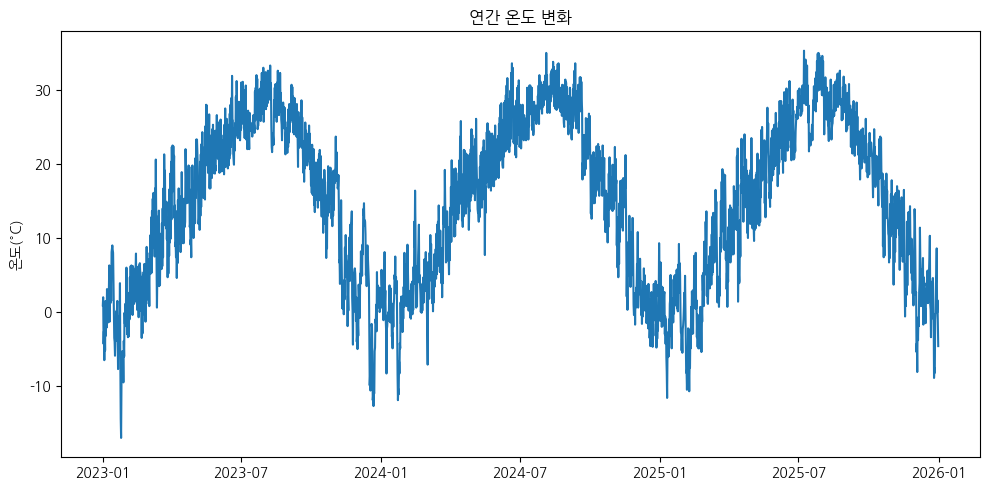

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df['일시'] = pd.to_datetime(df["일시"])   # 날짜 형식 변환
annual_df = df.iloc[::12]   # 12시간 간격 샘플링

plt.figure(figsize=(10, 5))

plt.plot(annual_df["일시"], annual_df["기온(°C)"])

plt.rcParams['axes.unicode_minus'] = False

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.title("연간 온도 변화")
plt.ylabel("온도(°C)")
plt.tight_layout()

plt.show()

In [ ]:
# 새로운 데이터셋 생성
df = df[["일시", "풍속(m/s)", "풍향(16방위)", "습도(%)", "현지기압(hPa)", "기온(°C)"]]

# 상위 데이터 출력
df.head()

,일시,풍속(m/s),풍향(16방위),습도(%),현지기압(hPa),기온(°C)
0,2023-01-01 00:00:00,1.4,200.0,72,1018.5,0.9
1,2023-01-01 01:00:00,1.9,250.0,71,1018.0,1.5
2,2023-01-01 02:00:00,1.9,250.0,72,1017.8,1.5
3,2023-01-01 03:00:00,1.6,250.0,74,1018.1,1.6
4,2023-01-01 04:00:00,1.4,290.0,74,1018.1,1.5


In [ ]:
# 새로운 데이터셋 저장
df.to_csv('/content/drive/MyDrive/Datasets/weather.csv', index=False)

In [ ]:
# 데이터셋 준비
df = pd.read_csv("/content/drive/MyDrive/Datasets/weather.csv")

print(df.shape)   # 데이터셋 shape 확인
print(df.columns)   # 컬럼명 확인

(26304, 6)
Index(['일시', '풍속(m/s)', '풍향(16방위)', '습도(%)', '현지기압(hPa)', '기온(°C)'], dtype='object')


In [ ]:
print(df.shape)   # 데이터셋 shape 확인
print(df.columns)   # 컬럼명 확인

(26304, 27)
Index(['지점', '일시', '기온(°C)', '강수량(mm)', '풍속(m/s)', '풍향(16방위)', '습도(%)',
       '증기압(hPa)', '이슬점온도(°C)', '현지기압(hPa)', '해면기압(hPa)', '일조(hr)',
       '일사(MJ/m2)', '적설(cm)', '3시간신적설(cm)', '전운량(10분위)', '중하층운량(10분위)',
       '운형(운형약어)', '최저운고(100m )', '시정(10m)', '지면상태(지면상태코드)', '현상번호(국내식)',
       '지면온도(°C)', '5cm 지중온도(°C)', '10cm 지중온도(°C)', '20cm 지중온도(°C)',
       '30cm 지중온도(°C)'],
      dtype='object')


In [1]:
# 예제 6.1 온도 예측(GRU)

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
# 예제 6.1 온도 예측(GRU)

# 셋업
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# 데이터셋 준비
df = pd.read_csv("/content/drive/MyDrive/Datasets/weather.csv")

print(df.shape)   # 데이터셋 shape 확인
print(df.columns)   # 컬럼명 확인

(26304, 6)
Index(['일시', '풍속(m/s)', '풍향(16방위)', '습도(%)', '현지기압(hPa)', '기온(°C)'], dtype='object')


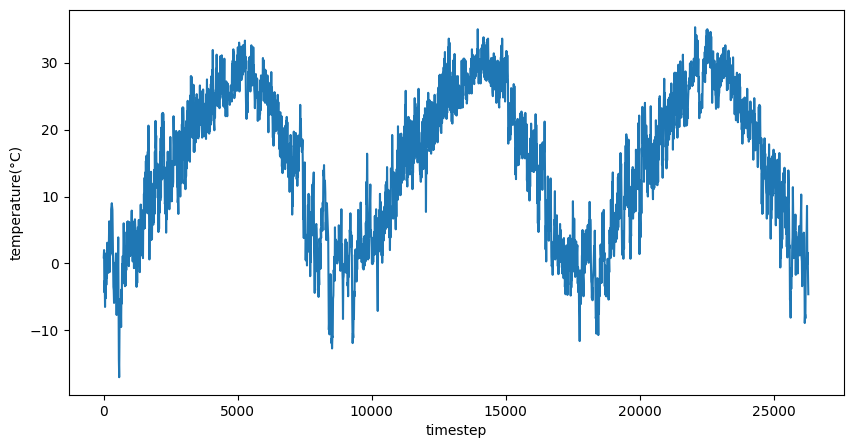

In [4]:
# 학습 데이터 시각화
plt.figure(figsize=(10, 5))

plt.plot(df.iloc[::12]["기온(°C)"])   # 12시간 간격 샘플링
plt.xlabel("timestep")
plt.ylabel("temperature(°C)")

plt.show()

In [ ]:
# 상위 데이터 출력
df.head()

,일시,풍속(m/s),풍향(16방위),습도(%),현지기압(hPa),기온(°C)
0,2023-01-01 00:00:00,1.4,200.0,72,1018.5,0.9
1,2023-01-01 01:00:00,1.9,250.0,71,1018.0,1.5
2,2023-01-01 02:00:00,1.9,250.0,72,1017.8,1.5
3,2023-01-01 03:00:00,1.6,250.0,74,1018.1,1.6
4,2023-01-01 04:00:00,1.4,290.0,74,1018.1,1.5


In [ ]:
# 불필요한 컬럼 제거
df = df.drop(["일시"], axis=1)

In [ ]:
# 데이터셋 정보 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26304 entries, 0 to 26303
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   풍속(m/s)    26236 non-null  float64
 1   풍향(16방위)   26236 non-null  float64
 2   습도(%)      26304 non-null  int64  
 3   현지기압(hPa)  26304 non-null  float64
 4   기온(°C)     26304 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 1.0 MB


In [ ]:
# 결측치 있는 행 삭제
df = df.dropna()

In [ ]:
# 통계 요약
df.describe().round(2)

,풍속(m/s),풍향(16방위),습도(%),현지기압(hPa),기온(°C)
count,26236.00,26236.00,26236.00,26236.00,26236.00
mean,2.31,181.56,66.07,1005.32,14.39
std,1.11,106.44,18.39,8.12,11.07
min,0.00,0.00,13.00,981.40,-17.20
25%,1.50,70.00,53.00,999.10,4.80
50%,2.20,230.00,67.00,1005.10,15.60
75%,2.90,270.00,81.00,1011.80,24.00
max,8.40,360.00,100.00,1027.40,37.60


In [ ]:
# 학습/테스트 데이터 분할
train_size = int(0.8 * len(df))

train_df = df[:train_size]
test_df = df[train_size:]

print(train_df.shape)   # 학습 데이터 shape 확인
print(test_df.shape)   # 테스트 데이터 shape 확인

(20988, 5)
(5248, 5)


In [ ]:
# 정규화
train_df = train_df.astype(float)
test_df = test_df.astype(float)

x_scaler = MinMaxScaler()
train_df.iloc[ : , :-1] = x_scaler.fit_transform(train_df.iloc[ : , :-1])
test_df.iloc[ : , :-1] = x_scaler.transform(test_df.iloc[ : , :-1])

y_scaler = MinMaxScaler()
train_df.iloc[ : , -1] = y_scaler.fit_transform(train_df.iloc[ : , [-1]]).ravel()
test_df.iloc[ : , -1] = y_scaler.transform(test_df.iloc[ : , [-1]]).ravel()

In [ ]:
# 정규화 후 통계 확인
train_df.describe().loc[["count", "mean", "std", "min", "max"]].round(2)

,풍속(m/s),풍향(16방위),습도(%),현지기압(hPa),기온(°C)
count,20988.00,20988.00,20988.00,20988.00,20988.00
mean,0.28,0.51,0.60,0.53,0.57
std,0.14,0.30,0.21,0.17,0.20
min,0.00,0.00,0.00,0.00,0.00
max,1.00,1.00,1.00,1.00,1.00


In [ ]:
# 텐서 변환
train_tensor = torch.tensor(train_df.values, dtype=torch.float32)
test_tensor  = torch.tensor(test_df.values, dtype=torch.float32)

In [ ]:
# 시퀀스 윈도우 생성 함수 정의
def sequence_window(data, seq_length, offset):
    x = []
    y = []

    for i in range(len(data) - seq_length - offset  + 1):
        x.append(data[i: i + seq_length])   # target(기온) 포함
        y.append(data[i + seq_length + offset - 1, [-1]])

    x = np.array(x)
    y = np.array(y).reshape(-1, 1)

    return x, y

In [ ]:
# 시퀀스 데이터셋 생성
x_train, y_train = sequence_window(np.array(train_df),
                                   seq_length=72,   # 3일(3*24시간)
                                   offset=24)   # 1일(24시간)
x_test, y_test = sequence_window(np.array(test_df), seq_length=72, offset=24)

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(20893, 72, 5) (20893, 1)
(5153, 72, 5) (5153, 1)


In [ ]:
# 텐서 변환
x_train = torch.FloatTensor(x_train)
y_train = torch.FloatTensor(y_train)

x_test = torch.FloatTensor(x_test)
y_test = torch.FloatTensor(y_test)

In [ ]:
# 데이터셋 생성
train_dataset = TensorDataset(x_train, y_train)
test_dataset  = TensorDataset(x_test, y_test)

In [ ]:
# 데이터 로더 생성
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
# 모델 생성
class TemperatureModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        gru_output, _ = self.gru(x)   # x(batch, sequence_length, input_size)
        last_hs = gru_output[:, -1, :]   # 마지막 타임 스텝
        output = self.fc(last_hs)   # 출력
        return output

# 디바이스 지정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 모델 생성
model = TemperatureModel(input_size=5, hidden_size=16, num_layers=2).to(device)

In [ ]:
!pip install torchinfo

In [ ]:
# 모델 구조 요약
from torchinfo import summary

summary(model, input_size=(1, 3, 5))  # 배치 크기 1, 입력(3, 5)

Layer (type:depth-idx)                   Output Shape              Param #
TemperatureModel                         [1, 1]                    --
├─GRU: 1-1                               [1, 3, 16]                2,736
├─Linear: 1-2                            [1, 1]                    17
Total params: 2,753
Trainable params: 2,753
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.01
Estimated Total Size (MB): 0.01

In [ ]:
# 하이퍼파라미터 설정
loss_fn = nn.MSELoss()   # 손실 함수로 MSE 사용
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# 모델 학습
model.train()   # 학습 모드

epochs = 5
losses = []   # 손실 리스트

for epoch in range(epochs):
    train_loss = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()   # 그레디언트 초기화
        outputs = model(inputs)   # 출력 계산
        loss = loss_fn(outputs, targets)   # 손실 계산

        loss.backward()   # 역전파
        optimizer.step()   # 최적화 수행

        train_loss += loss.item() * inputs.size(0)

    train_loss /= len(train_loader.dataset)   # 학습 손실
    losses.append(train_loss)  # 손실 저장(학습 결과 시각화용)

    print(f"Epoch {epoch+1} \t loss: {train_loss:.4f}")

Epoch 1 	 loss: 0.0132
Epoch 2 	 loss: 0.0039
Epoch 3 	 loss: 0.0036
Epoch 4 	 loss: 0.0034
Epoch 5 	 loss: 0.0034


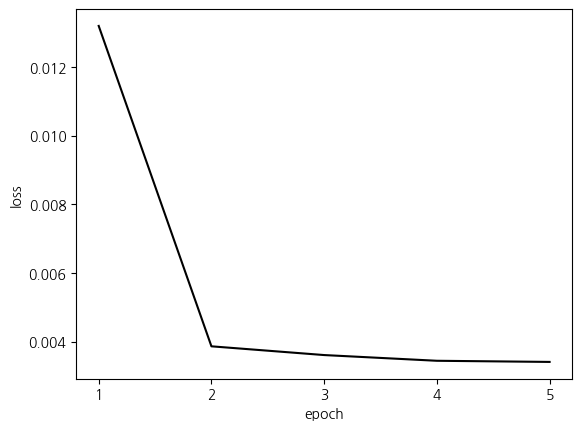

In [ ]:
# 학습 결과 시각화
plt.plot(range(1, epochs + 1), losses, color="black")
plt.xticks(range(1, epochs + 1))
plt.xlabel("epoch")
plt.ylabel("loss")

plt.show()

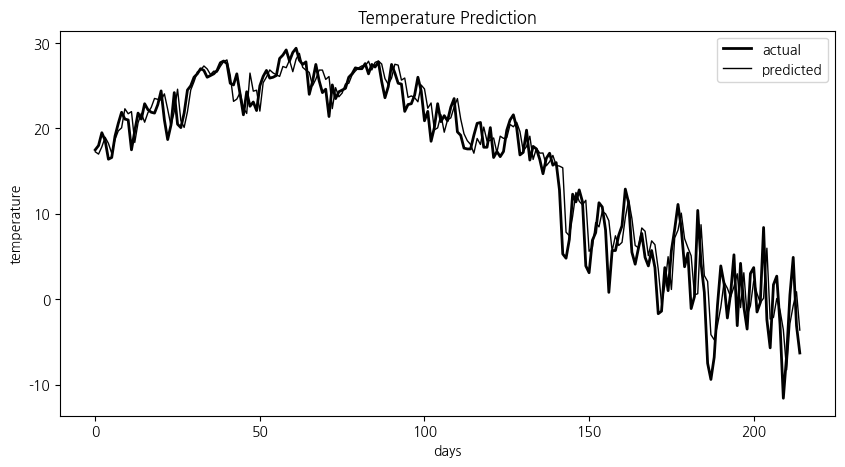

In [ ]:
# 예측 결과 시각화
model.eval()

predicted = []
actual = []

with torch.no_grad():   # 예측할 때에는 자동 미분하지 않음
    for inputs, target in test_loader:
        inputs, target = inputs.to(device), target.to(device)
        predict = model(inputs)   # 예측

        actual.append(target.cpu())
        predicted.append(predict.cpu())

predicted = torch.cat(predicted, dim=0).numpy()
actual = torch.cat(actual, dim=0).numpy()

actual = y_scaler.inverse_transform(actual)   # 역정규화
predicted = y_scaler.inverse_transform(predicted)

plt.figure(figsize=(10, 5))

plt.plot(actual[::24], label="actual", color="black", linewidth=2)
plt.plot(predicted[::24], label="predicted", color="black", linewidth=1)

plt.title("Temperature Prediction")
plt.xlabel("days")
plt.ylabel("temperature")
plt.legend()

plt.show()

In [ ]:
# 예제 6.2 주가 예측(LSTM)(파이토치)

# finance-datareader 설치
!pip install finance-datareader

In [ ]:
# 셋업
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import FinanceDataReader as fdr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# 데이터셋 준비
df = fdr.DataReader("005930", "2020-01-01", "2025-12-31")

print(df.shape)   # 데이터셋 shape 확인
print(df.columns)   # 데이터셋 컬럼 확인

(1473, 6)
Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Change'], dtype='object')


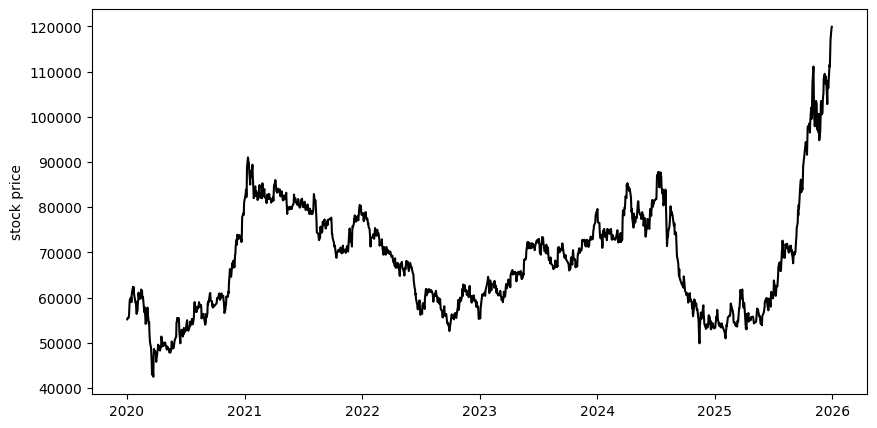

In [ ]:
# 학습 데이터 시각화
plt.figure(figsize=(10, 5))

plt.plot(df["Close"], color="black")
plt.ylabel("stock price")

plt.show()

In [ ]:
# 불필요한 컬럼(Change) 제거/종가 맨 뒤에 배치
df = df[["Open", "High", "Low", "Volume", "Close"]]

# 상위 데이터 확인
df.head()

,Open,High,Low,Volume,Close
Date,,,,,
2020-01-02,55500,56000,55000,12993228,55200
2020-01-03,56000,56600,54900,15422255,55500
2020-01-06,54900,55600,54600,10278951,55500
2020-01-07,55700,56400,55600,10009778,55800
2020-01-08,56200,57400,55900,23501171,56800


In [ ]:
# 학습/테스트 데이터 분할
train_size = int(0.8 * len(df))

train_df = df[:train_size]
test_df = df[train_size:]

In [ ]:
# 정규화
train_df = train_df.astype(float)
test_df = test_df.astype(float)

x_scaler = MinMaxScaler()
train_df.iloc[ : , :-1] = x_scaler.fit_transform(train_df.iloc[ : , :-1])
test_df.iloc[ : , :-1] = x_scaler.transform(test_df.iloc[ : , :-1])

y_scaler = MinMaxScaler()
train_df.iloc[ : , -1] = y_scaler.fit_transform(train_df.iloc[ : , [-1]]).ravel()
test_df.iloc[ : , -1] = y_scaler.transform(test_df.iloc[ : , [-1]]).ravel()

In [ ]:
# 정규화 후 통계 확인
train_df.describe().loc[["count", "mean", "std", "min", "max"]].round(2)

,Open,High,Low,Volume,Close
count,1178.00,1178.00,1178.00,1178.00,1178.00
mean,0.54,0.48,0.54,0.14,0.53
std,0.21,0.19,0.21,0.10,0.21
min,0.00,0.00,0.00,0.00,0.00
max,1.00,1.00,1.00,1.00,1.00


In [ ]:
# 텐서 변환
train_tensor = torch.tensor(train_df.values, dtype=torch.float32)
test_tensor  = torch.tensor(test_df.values, dtype=torch.float32)

In [ ]:
# 시퀀스 윈도우 생성 함수 정의
def sequence_window(data, seq_length, offset):
    x = []
    y = []

    for i in range(len(data) - seq_length - offset  + 1):
        x.append(data[i: i + seq_length, : -1])   # target(종가) 제외
        y.append(data[i + seq_length + offset - 1, [-1]])

    x = np.array(x)
    y = np.array(y).reshape(-1, 1)

    return x, y

In [ ]:
# 시퀀스 데이터셋 생성
x_train, y_train = sequence_window(np.array(train_df), seq_length=3, offset=1)
x_test, y_test = sequence_window(np.array(test_df), seq_length=3, offset=1)

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(1175, 3, 4) (1175, 1)
(292, 3, 4) (292, 1)


In [ ]:
# 텐서 변환
x_train = torch.FloatTensor(x_train)
y_train = torch.FloatTensor(y_train)

x_test = torch.FloatTensor(x_test)
y_test = torch.FloatTensor(y_test)

In [ ]:
# 데이터셋 생성
train_dataset = TensorDataset(x_train, y_train)
test_dataset  = TensorDataset(x_test, y_test)

In [ ]:
# 데이터 로더 생성
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
# 모델 생성
class StockModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_output, _ = self.lstm(x)   # x(batch, sequence_length, input_size)
        last_hs = lstm_output[:, -1, :]   # 마지막 타임 스텝
        output = self.fc(last_hs)   # 출력
        return output

# 디바이스 지정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 모델 생성
model = StockModel(input_size=4, hidden_size=16, num_layers=2).to(device)

In [ ]:
!pip install torchinfo

In [ ]:
# 모델 구조 요약
from torchinfo import summary

summary(model, input_size=(1, 3, 4))  # 배치 크기 1, 입력(3, 4)

Layer (type:depth-idx)                   Output Shape              Param #
StockModel                               [1, 1]                    --
├─LSTM: 1-1                              [1, 3, 16]                3,584
├─Linear: 1-2                            [1, 1]                    17
Total params: 3,601
Trainable params: 3,601
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.01
Estimated Total Size (MB): 0.01

In [ ]:
# 하이퍼파라미터 설정
loss_fn = nn.MSELoss()   # 손실 함수로 MSE 사용
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# 모델 학습
model.train()   # 학습 모드

epochs = 20
losses = []   # 손실 리스트

for epoch in range(epochs):
    train_loss = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()   # 그레디언트 초기화
        outputs = model(inputs)   # 출력 계산
        loss = loss_fn(outputs, targets)   # 손실 계산

        loss.backward()   # 역전파
        optimizer.step()   # 최적화 수행

        train_loss += loss.item() * inputs.size(0)

    train_loss /= len(train_loader.dataset)   # 학습 손실
    losses.append(train_loss)  # 손실 저장(학습 결과 시각화용)

    if epoch == 0 or (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1} \t loss: {train_loss:.4f}")

Epoch 1 	 loss: 0.2629
Epoch 5 	 loss: 0.0033
Epoch 10 	 loss: 0.0012
Epoch 15 	 loss: 0.0011
Epoch 20 	 loss: 0.0011


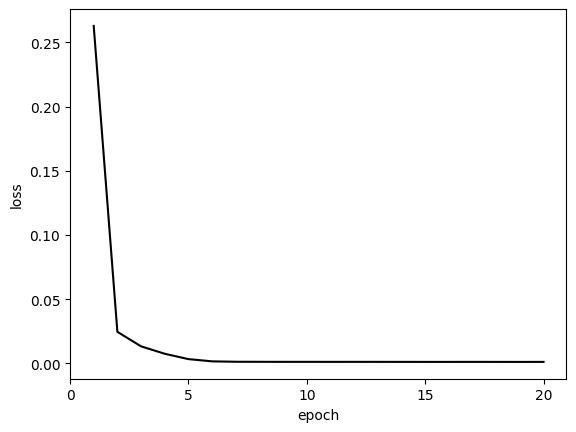

In [ ]:
# 학습 결과 시각화
plt.plot(range(1, epochs + 1), losses, color="black")
plt.xticks(range(0, epochs + 1, 5))
plt.xlabel("epoch")
plt.ylabel("loss")

plt.show()

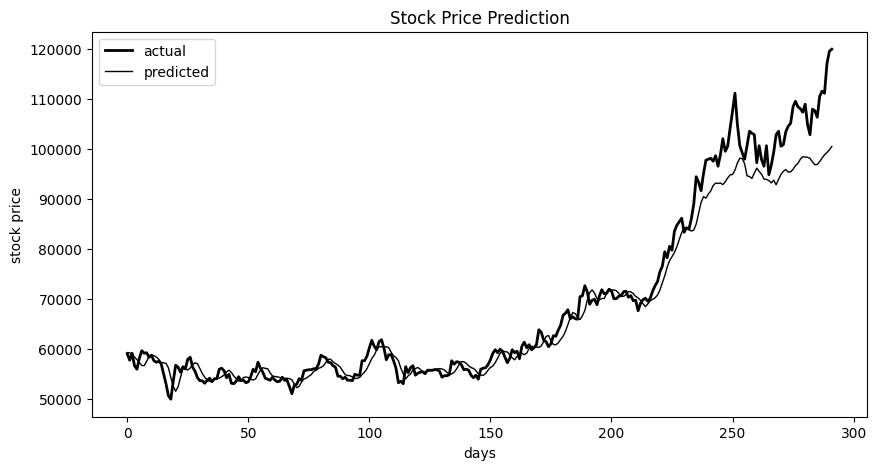

In [ ]:
# 예측 결과 시각화
model.eval()

predicted = []
actual = []

with torch.no_grad():   # 얘측할 때에는 자동 미분하지 않음
    for inputs, target in test_loader:
        inputs, target = inputs.to(device), target.to(device)
        predict = model(inputs)   # 예측

        actual.append(target.cpu())
        predicted.append(predict.cpu())

predicted = torch.cat(predicted, dim=0).numpy()
actual = torch.cat(actual, dim=0).numpy()

actual = y_scaler.inverse_transform(actual)   # 역정규화
predicted = y_scaler.inverse_transform(predicted)

plt.figure(figsize=(10, 5))

plt.plot(actual, label="actual", color="black", linewidth=2)
plt.plot(predicted, label="predicted", color="black", linewidth=1)
plt.title("Stock Price Prediction")
plt.xlabel("days")
plt.ylabel("stock price")
plt.legend()

plt.show()